In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 400
mileage_km = np.random.uniform(5000, 150000, n)
age_years = np.random.uniform(0, 15, n)
engine_size_L = np.random.uniform(1.0, 4.0, n)
fuel_type = np.random.choice(["Petrol", "Diesel", "Electric"], n, p=[0.55, 0.35, 0.10])
price = 28000 - age_years*1400 - mileage_km*0.04 + engine_size_L*1500 + np.random.normal(0, 1200, n)

messy = pd.DataFrame({
    "mileage_km": mileage_km, "age_years": age_years,
    "engine_size_L": engine_size_L, "fuel_type": fuel_type, "price": price
})

# --- Inject missing values ---
for col, frac in [("mileage_km", 0.05), ("age_years", 0.03), ("price", 0.04), ("fuel_type", 0.03)]:
    idx = np.random.choice(messy.index, size=int(frac*n), replace=False)
    messy.loc[idx, col] = np.nan

# --- Inject outliers ---
outlier_idx = np.random.choice(messy.index, size=8, replace=False)
messy.loc[outlier_idx, "price"] = messy.loc[outlier_idx, "price"] * np.random.uniform(3, 5, 8)
outlier_idx2 = np.random.choice(messy.index, size=6, replace=False)
messy.loc[outlier_idx2, "mileage_km"] = messy.loc[outlier_idx2, "mileage_km"] * np.random.uniform(3, 6, 6)

print(messy.isna().sum())
print()
messy.describe()

mileage_km       20
age_years        12
engine_size_L     0
fuel_type        12
price            16
dtype: int64



,mileage_km,age_years,engine_size_L,price
count,380.000000,388.000000,400.000000,384.000000
mean,80034.237214,7.580193,2.510664,19144.873642
std,50428.151846,4.391011,0.890499,9986.142210
min,5733.929658,0.162565,1.013896,3995.571960
25%,41452.629729,3.764574,1.697913,13168.339260
50%,80760.766484,7.601243,2.556634,19059.407481
75%,114638.107821,11.426215,3.293504,23523.503199
max,438846.704221,14.995765,3.993802,123279.502739


In [ ]:
from sklearn.impute import SimpleImputer

num_cols = ["mileage_km", "age_years", "engine_size_L", "price"]
cat_cols = ["fuel_type"]

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

clean = messy.copy()
clean[num_cols] = num_imputer.fit_transform(clean[num_cols])
clean[cat_cols] = cat_imputer.fit_transform(clean[cat_cols])

print("Missing values after imputation:")
print(clean.isna().sum())

Missing values after imputation:
mileage_km       0
age_years        0
engine_size_L    0
fuel_type        0
price            0
dtype: int64


In [ ]:
def cap_outliers_iqr(df, col, k=1.5):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k*iqr, q3 + k*iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    return n_outliers

# Keep a "before" copy for the box plot comparison
before_price = clean["price"].copy()
before_mileage = clean["mileage_km"].copy()

for col in ["price", "mileage_km"]:
    n = cap_outliers_iqr(clean, col)
    print(f"{col}: outliers capped = {n}")

price: outliers capped = 6
mileage_km: outliers capped = 3


/tmp/ipykernel_1092/3382530940.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([before_price, clean["price"]], labels=["Before", "After"])
/tmp/ipykernel_1092/3382530940.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([before_mileage, clean["mileage_km"]], labels=["Before", "After"])


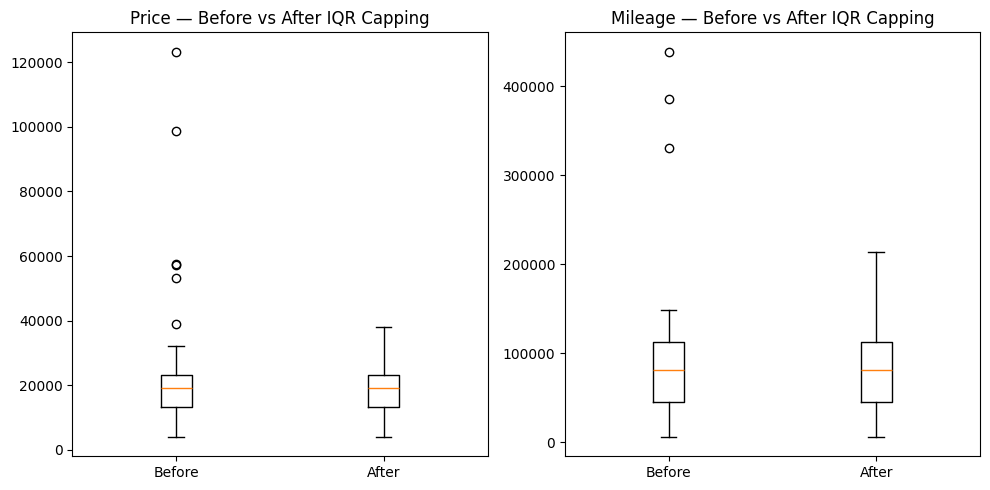

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].boxplot([before_price, clean["price"]], labels=["Before", "After"])
axes[0].set_title("Price — Before vs After IQR Capping")

axes[1].boxplot([before_mileage, clean["mileage_km"]], labels=["Before", "After"])
axes[1].set_title("Mileage — Before vs After IQR Capping")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop="first")
fuel_encoded = pd.DataFrame(
    encoder.fit_transform(clean[["fuel_type"]]),
    columns=encoder.get_feature_names_out(["fuel_type"])
)

scaler = StandardScaler()
scaled_num = pd.DataFrame(scaler.fit_transform(clean[num_cols]), columns=num_cols)

processed = pd.concat([scaled_num, fuel_encoded], axis=1)
processed.head()

,mileage_km,age_years,engine_size_L,price,fuel_type_Electric,fuel_type_Petrol
0,-0.455375,-1.397052,0.687050,1.292587,0.0,0.0
1,1.497876,1.379341,-1.184016,-2.104242,0.0,1.0
2,0.756406,-0.000472,0.245340,-0.349398,0.0,1.0
3,0.304394,1.115064,0.347972,-1.306945,0.0,1.0
4,0.046173,-0.643676,-0.267906,0.731516,0.0,1.0
